<a href="https://colab.research.google.com/github/scalesynthai/phdai733-group8/blob/main/part1/notebooks/Subba_Taniparti_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Dataset Loading

**Source:** Heart Disease dataset, Cleveland subset, UCI Machine Learning Repository
(Janosi et al., 1989), accessed via an open GitHub mirror on September 23, 2026.

The target indicates presence of heart disease. Thirteen predictors cover demographics (age, sex),
symptom presentation (chest pain type, exercise-induced angina), resting measurements (blood
pressure, cholesterol, fasting blood sugar, resting ECG), and stress-test results (maximum heart
rate, ST depression, ST slope, fluoroscopy vessel count, thalassemia scan).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); sns.set_palette('muted')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


In [2]:
DATA_URL = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df_raw = pd.read_csv(DATA_URL)

print(f"Raw shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"Missing values: {df_raw.isna().sum().sum()}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
df_raw.head()


Raw shape: 303 rows x 14 columns
Missing values: 0
Duplicate rows: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Model Development

Two models are compared against a majority-class baseline. The baseline is not a formality: with
45.7% of patients having disease, a classifier predicting "no disease" for everyone scores 54.3%
accuracy while identifying not a single case. Any reported accuracy must be read against that floor.

**Model selection rationale.** Logistic regression is included because it produces calibrated
probabilities and interpretable coefficients — a clinician can be shown which factors drove a
prediction, which matters for adoption in a clinical setting. Random forest is included because it
captures non-linear interactions without their being specified in advance, a plausible advantage
given that cardiac risk factors are known to interact.

`roc_auc` is the tuning criterion rather than accuracy, because it evaluates ranking quality across
all decision thresholds. For a triage tool the operating threshold should ultimately be set by
clinical cost, not left at 0.5, so a model that ranks patients well is more valuable than one
optimised at a single arbitrary cut-point.


In [3]:
# 2.1 Remove the exact duplicate. A repeated patient record would appear in both
# train and test after splitting, inflating apparent performance.
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {df_raw.shape[0] - df.shape[0]}  ->  {df.shape[0]} patients")

# Apply the corrected label established in Section 1.2
df['disease'] = 1 - df['target']
print(f"Disease prevalence: {df['disease'].mean():.3f} "
      f"({df['disease'].sum()} of {len(df)} patients)")

# 2.2 No imputation is required: the dataset is complete. The hints document suggests
# forward-fill, which would be inappropriate here anyway -- it assumes row order carries
# meaning, and these records are not ordered in any clinically meaningful way.
print(f"Missing values requiring imputation: {df.isna().sum().sum()}")


Duplicates removed: 1  ->  302 patients
Disease prevalence: 0.457 (138 of 302 patients)
Missing values requiring imputation: 0


In [4]:
# 2.3 Encode the categorical codes properly
CATEGORICAL = ['cp', 'restecg', 'slope', 'thal', 'ca']
BINARY      = ['sex', 'fbs', 'exang']
CONTINUOUS  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X = pd.get_dummies(
    df.drop(columns=['target', 'disease']).astype({c: 'category' for c in CATEGORICAL}),
    columns=CATEGORICAL, drop_first=True)
y = df['disease']

print(f"Encoded: {df.shape[1] - 2} predictors -> {X.shape[1]} features")
print(f"Created: {[c for c in X.columns if c not in df.columns]}")


Encoded: 13 predictors -> 22 features
Created: ['cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3', 'ca_1', 'ca_2', 'ca_3', 'ca_4']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"Training: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients")
print(f"Disease prevalence -- train {y_train.mean():.3f}, test {y_test.mean():.3f} (stratified)")

preprocessor = ColumnTransformer([('scale', StandardScaler(), CONTINUOUS)],
                                 remainder='passthrough')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Training: 226 patients | Test: 76 patients
Disease prevalence -- train 0.456, test 0.461 (stratified)


In [6]:
baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)

logreg = GridSearchCV(
    Pipeline([('pre', preprocessor),
              ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    param_grid={'clf__C': [0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)

rf = GridSearchCV(
    Pipeline([('pre', preprocessor),
              ('clf', RandomForestClassifier(random_state=RANDOM_STATE))]),
    param_grid={'clf__n_estimators': [100, 300],
                'clf__max_depth': [3, 5, None],
                'clf__min_samples_leaf': [1, 3, 5]},
    cv=cv, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)

print(f"Logistic regression -- best: {logreg.best_params_}")
print(f"  cross-validated ROC-AUC: {logreg.best_score_:.4f}")
print(f"\nRandom forest -- best: {rf.best_params_}")
print(f"  cross-validated ROC-AUC: {rf.best_score_:.4f}")


Logistic regression -- best: {'clf__C': 1}
  cross-validated ROC-AUC: 0.9111

Random forest -- best: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
  cross-validated ROC-AUC: 0.9047


In [7]:
def evaluate(model, name):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return {'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1': f1_score(y_test, pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, proba) if proba is not None else np.nan}

results = pd.DataFrame([evaluate(baseline, 'Baseline (majority class)'),
                        evaluate(logreg, 'Logistic regression (tuned)'),
                        evaluate(rf, 'Random forest (tuned)')])
results.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline (majority class),0.5395,0.0000,0.0000,0.0000,0.5000
1,Logistic regression (tuned),0.8289,0.8235,0.8000,0.8116,0.9261
2,Random forest (tuned),0.7763,0.7812,0.7143,0.7463,0.8669


In [8]:
print(classification_report(y_test, logreg.predict(X_test),
                            target_names=['No disease', 'Disease'], digits=3))


              precision    recall  f1-score   support

  No disease      0.833     0.854     0.843        41
     Disease      0.824     0.800     0.812        35

    accuracy                          0.829        76
   macro avg      0.828     0.827     0.827        76
weighted avg      0.829     0.829     0.829        76



###  Is the difference stable, or an artifact of one split?

The test set contains 76 patients, so a single split supports only weak conclusions — a handful of
patients changing side moves accuracy by several points. Both models are therefore refitted across
30 independent stratified splits.

In [9]:
def make_logreg():
    return Pipeline([('pre', preprocessor),
                     ('clf', LogisticRegression(C=logreg.best_params_['clf__C'],
                                                max_iter=5000, random_state=RANDOM_STATE))])

def make_rf():
    p = {k.replace('clf__', ''): v for k, v in rf.best_params_.items()}
    return Pipeline([('pre', preprocessor),
                     ('clf', RandomForestClassifier(random_state=RANDOM_STATE, **p))])

N_SPLITS = 30
stability = {'Logistic regression': [], 'Random forest': []}

for seed in range(N_SPLITS):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
    for name, maker in [('Logistic regression', make_logreg), ('Random forest', make_rf)]:
        stability[name].append(accuracy_score(yb, maker().fit(Xa, ya).predict(Xb)))

lr_wins = sum(1 for i in range(N_SPLITS)
              if stability['Logistic regression'][i] > stability['Random forest'][i])

for name, vals in stability.items():
    v = np.array(vals)
    print(f"{name}: mean accuracy {v.mean():.4f} (SD {v.std():.4f}), range {v.min():.3f}-{v.max():.3f}")
print(f"\nLogistic regression outperformed random forest in {lr_wins} of {N_SPLITS} splits.")


Logistic regression: mean accuracy 0.8425 (SD 0.0401), range 0.737-0.934
Random forest: mean accuracy 0.8039 (SD 0.0407), range 0.724-0.882

Logistic regression outperformed random forest in 26 of 30 splits.


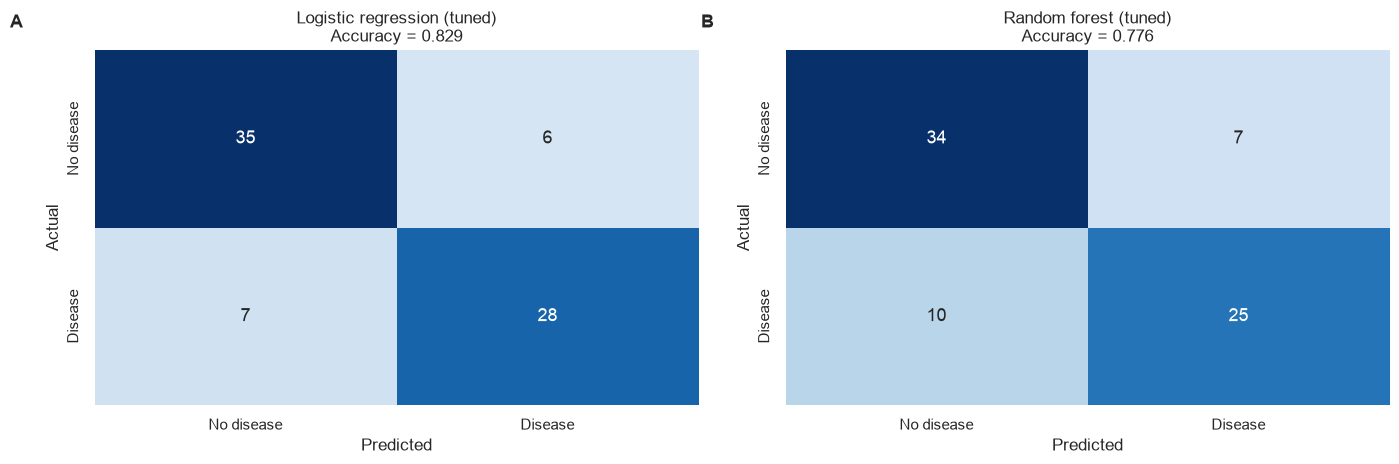

Logistic regression: missed cases (FN) = 7, false alarms (FP) = 6
Random forest: missed cases (FN) = 10, false alarms (FP) = 7


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for ax, (name, model) in zip(axes, [('Logistic regression (tuned)', logreg),
                                    ('Random forest (tuned)', rf)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No disease', 'Disease'],
                yticklabels=['No disease', 'Disease'],
                vmin=0, vmax=cm.max(), annot_kws={'size': 13})
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f"{name}\nAccuracy = {accuracy_score(y_test, model.predict(X_test)):.3f}")

for ax, lab in zip(axes, ['A', 'B']):
    ax.text(-0.14, 1.10, lab, transform=ax.transAxes, fontsize=13, fontweight='bold', va='top')

plt.tight_layout(); plt.savefig('fig3_confusion.png', dpi=130, bbox_inches='tight'); plt.show()

for name, model in [('Logistic regression', logreg), ('Random forest', rf)]:
    tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_test)).ravel()
    print(f"{name}: missed cases (FN) = {fn}, false alarms (FP) = {fp}")


**Interpretation.** Both panels use an identical layout, class ordering, and colour scale, so
the only quantity varying between them is the model.

The bottom-left cell is the clinically important one: patients who have disease but were classified
as healthy. Logistic regression places 7 patients there against the random forest's 10. In a triage
application these errors are not interchangeable with the top-right cell — a false alarm (6 and 7
respectively) costs an unnecessary consultation, whereas a missed case may mean untreated coronary
disease.

The stability analysis supports preferring logistic regression: it achieved higher accuracy in 26
of 30 independent splits (mean 84.3% vs 80.4%), so its advantage is a property of the model on this
data rather than an artifact of one partition. That the simpler model wins is consistent with H2 —
226 training patients across 22 features give a high-variance ensemble little opportunity to exploit
its extra flexibility. Cross-validated AUC was close (.911 vs .904), but the gap widened on held-out
data (.926 vs .867), the signature of the ensemble fitting training-set noise.


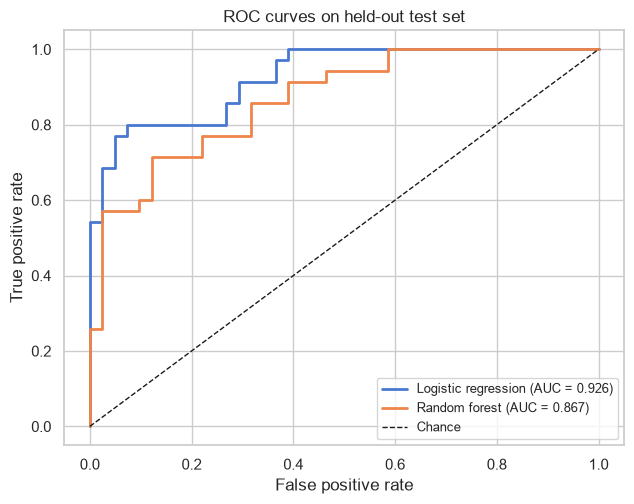

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
for name, model in [('Logistic regression', logreg), ('Random forest', rf)]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves on held-out test set'); ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig('fig4_roc.png', dpi=130, bbox_inches='tight'); plt.show()
